In [3]:
import pandas as pd

df = pd.read_csv("breast-cancer.csv")

# Check missing values
print(df.isnull())

# Check non-missing values
print(df.notnull())

# Count missing values in each column
print("\nMissing Values Count:\n", df.isnull().sum())

        id  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    False      False        False         False           False      False   
1    False      False        False         False           False      False   
2    False      False        False         False           False      False   
3    False      False        False         False           False      False   
4    False      False        False         False           False      False   
..     ...        ...          ...           ...             ...        ...   
564  False      False        False         False           False      False   
565  False      False        False         False           False      False   
566  False      False        False         False           False      False   
567  False      False        False         False           False      False   
568  False      False        False         False           False      False   

     smoothness_mean  compactness_mean  concavity_m

In [4]:
import pandas as pd

df = pd.read_csv("breast-cancer.csv")

print("Before Cleaning:", df.shape)

# Drop missing rows
cleaned_df = df.dropna()

print("After Cleaning:", cleaned_df.shape)

Before Cleaning: (569, 32)
After Cleaning: (569, 32)


In [5]:
import pandas as pd

df = pd.read_csv("breast-cancer.csv")

# Fill numerical columns with mean
df['area_se'].fillna(df['area_se'].mean(), inplace=True)

# Fill categorical columns
# df['City'].fillna("Unknown", inplace=True)

print(df)

           id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0      842302         M        17.99         10.38          122.80     1001.0   
1      842517         M        20.57         17.77          132.90     1326.0   
2    84300903         M        19.69         21.25          130.00     1203.0   
3    84348301         M        11.42         20.38           77.58      386.1   
4    84358402         M        20.29         14.34          135.10     1297.0   
..        ...       ...          ...           ...             ...        ...   
564    926424         M        21.56         22.39          142.00     1479.0   
565    926682         M        20.13         28.25          131.20     1261.0   
566    926954         M        16.60         28.08          108.30      858.1   
567    927241         M        20.60         29.33          140.10     1265.0   
568     92751         B         7.76         24.54           47.92      181.0   

     smoothness_mean  compa

C:\Users\sheer\AppData\Local\Temp\ipykernel_11764\695822112.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['area_se'].fillna(df['area_se'].mean(), inplace=True)


In [8]:
print("Before:\n", df.dtypes)

# Convert datatype
df['area_mean'] = df['area_mean'].astype(int)

print("\nAfter:\n", df.dtypes)

Before:
 id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_w

In [9]:
df.rename(columns={
    "area_mean": "area-mean",
    "area_worst": "area-worst"
}, inplace=True)

print(df.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area-mean  \
0    842302         M        17.99         10.38          122.80       1001   
1    842517         M        20.57         17.77          132.90       1326   
2  84300903         M        19.69         21.25          130.00       1203   
3  84348301         M        11.42         20.38           77.58        386   
4  84358402         M        20.29         14.34          135.10       1297   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area-wor

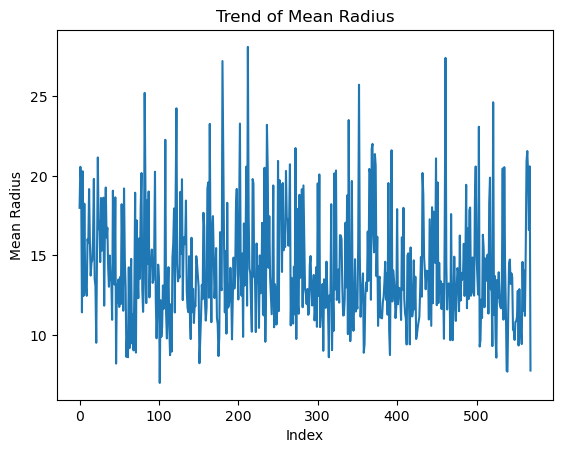

In [13]:
import matplotlib.pyplot as plt
# Line plot (trend of mean radius)
plt.plot(df['radius_mean'])
plt.title("Trend of Mean Radius")
plt.xlabel("Index")
plt.ylabel("Mean Radius")
plt.show()


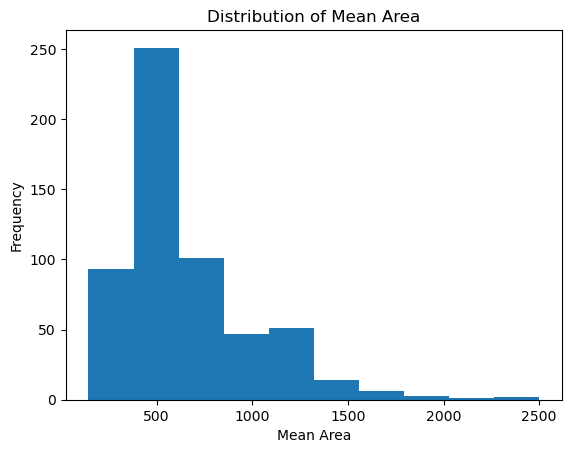

In [14]:
plt.hist(df['area-mean'])
plt.title("Distribution of Mean Area")
plt.xlabel("Mean Area")
plt.ylabel("Frequency")
plt.show()

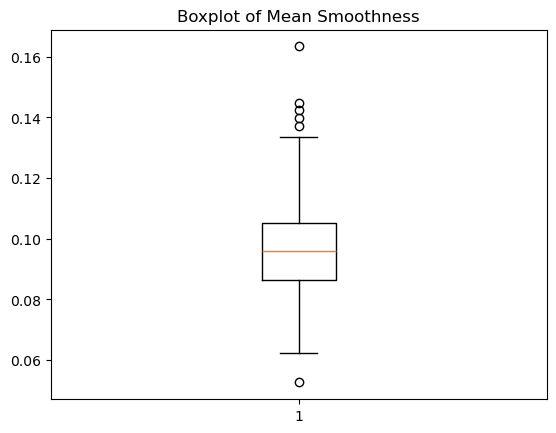

In [15]:
plt.boxplot(df['smoothness_mean'])
plt.title("Boxplot of Mean Smoothness")
plt.show()

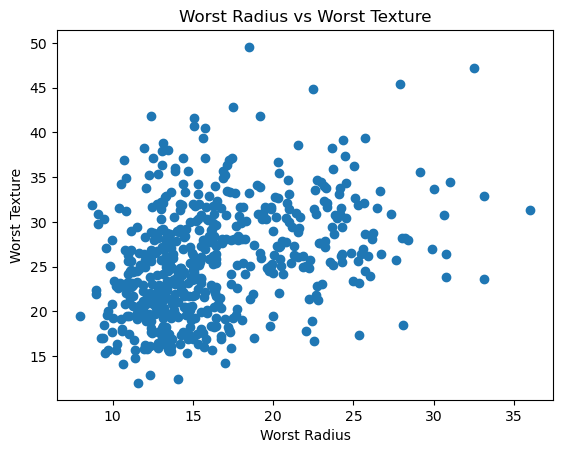

In [16]:
plt.scatter(df['radius_worst'], df['texture_worst'])
plt.xlabel("Worst Radius")
plt.ylabel("Worst Texture")
plt.title("Worst Radius vs Worst Texture")
plt.show()

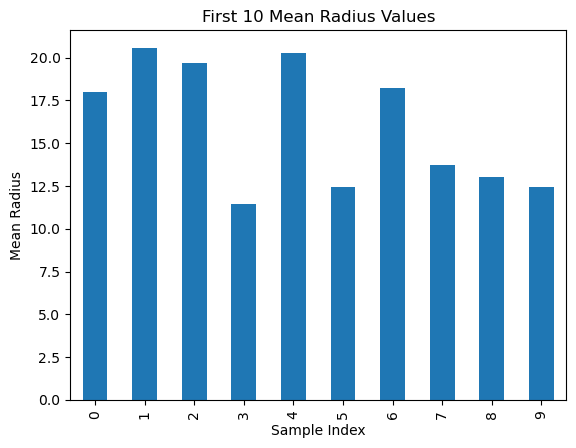

In [17]:
df['radius_mean'].head(10).plot(kind='bar')
plt.title("First 10 Mean Radius Values")
plt.xlabel("Sample Index")
plt.ylabel("Mean Radius")
plt.show()

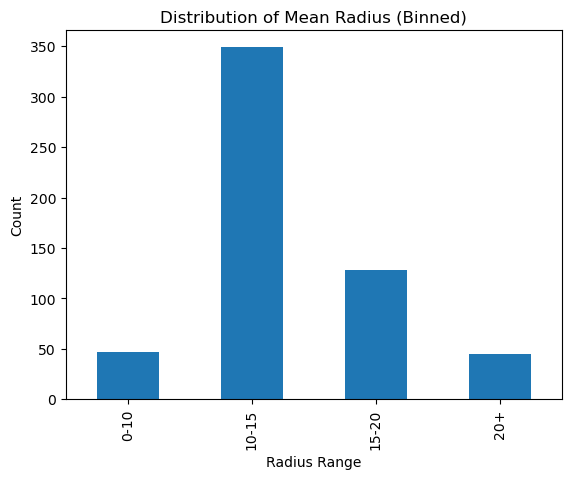

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Example: use 'mean radius'

# Create bins
bins = [0, 10, 15, 20, 30]
labels = ['0-10', '10-15', '15-20', '20+']

df['radius_group'] = pd.cut(df['radius_mean'], bins=bins, labels=labels)

# Count values in each bin
counts = df['radius_group'].value_counts().sort_index()

# Bar plot
counts.plot(kind='bar')
plt.title("Distribution of Mean Radius (Binned)")
plt.xlabel("Radius Range")
plt.ylabel("Count")
plt.show()